In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os


In [82]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / "data" / "processed"

df = pd.read_csv(PROC / "cleaned_apple_sales_enriched.csv")

In [83]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,976,True,0,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,6461,True,0,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,3416,True,0,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,923,True,0,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,15957,True,0,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020


In [84]:
df['gdp'].unique()

array([6.98564394e+03, 4.00287342e+04, 6.44015074e+04, 4.87164099e+04,
       8.84127075e+03, 2.72339427e+04, 3.71738754e+04, 1.06274638e+04,
       5.34679277e+04, 4.04048062e+04, 6.76900000e+11, 6.14100793e+04,
       3.17212989e+04, 5.17915402e+04, 5.33968711e+03, 4.35378393e+04,
       3.91698606e+04, 4.73797652e+04, 3.20914867e+04, 1.28874357e+04,
       4.33600211e+04, 5.22656542e+04, 8.00561288e+04, 7.13074017e+04,
       6.01419881e+04, 6.06077789e+04, 5.28866616e+04, 7.05720755e+03,
       6.22262164e+03, 3.68525425e+04, 1.03140507e+04, 4.69264757e+04,
       7.76900000e+11, 4.37251000e+04, 4.00945600e+04, 3.51255225e+04,
       3.07994776e+04, 5.36487191e+04, 5.62568007e+04, 5.91233186e+04,
       6.49970137e+04, 3.02702687e+04, 4.98990653e+04, 7.78609113e+04,
       9.02990695e+04, 4.60629914e+04, 1.29706056e+04, 6.90935282e+03,
       1.14021410e+04, 4.10828119e+04, 3.40656439e+04, 6.68044507e+03,
       3.23946834e+04, 4.96861155e+04, 5.21766649e+04, 3.56539042e+04,
      

In [85]:
df['gdp'].describe()


count    1.040200e+06
mean     1.907144e+10
std      1.549602e+11
min      5.339687e+03
25%      3.383618e+04
50%      4.920081e+04
75%      6.457201e+04
max      1.869700e+12
Name: gdp, dtype: float64

In [86]:
df.sort_values('gdp', ascending=False).head(10)


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year
1040138,HQ-15003,2024-11-12,ST-71,P-9,5,MacBook Pro (Touch Bar),2024-06-17,1304,Apple Yeouido,Seoul,...,6520,False,148,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893834,RH-03176,2024-03-07,ST-71,P-53,1,Apple Watch Series 5,2023-11-10,1296,Apple Yeouido,Seoul,...,1296,False,118,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893805,IW-0153,2024-03-07,ST-70,P-23,6,iPad (9th Generation),2022-03-08,1949,Apple Gangnam,Seoul,...,11694,False,730,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
1040075,PJ-161238,2024-11-12,ST-71,P-14,6,AirPods Pro (2nd Generation),2021-01-29,696,Apple Yeouido,Seoul,...,4176,False,1383,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
1040034,OI-947766,2024-11-12,ST-70,P-45,8,Apple Watch Series 9,2020-09-12,1014,Apple Gangnam,Seoul,...,8112,False,1522,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
893794,VB-96996,2024-03-07,ST-70,P-60,3,iMac with Retina Display,2020-07-24,343,Apple Gangnam,Seoul,...,1029,False,1322,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918450,RJ-90927,2024-04-18,ST-71,P-44,1,iPhone 12 Pro Max,2020-09-09,544,Apple Yeouido,Seoul,...,544,False,1317,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918306,IC-329999,2024-04-18,ST-70,P-9,9,MacBook Pro (Touch Bar),2020-01-01,1304,Apple Gangnam,Seoul,...,11736,True,1569,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918309,KB-96957,2024-04-18,ST-70,P-66,10,Mac Mini (M2),2021-10-30,874,Apple Gangnam,Seoul,...,8740,False,901,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024
918477,YY-879356,2024-04-18,ST-71,P-55,1,Apple TV HD,2021-11-24,1258,Apple Yeouido,Seoul,...,1258,False,876,1.869700e+12,1363.375,2.321743,97.8956,south korea,"korea, rep.",2024


In [87]:
import numpy as np

# أكبر قيمة
print("Max GDP:", df['gdp'].max())

# عدد القيم اللي أكبر من 200 ألف
large_values = df[df['gdp'] > 200_000]
print("Count of suspicious large values:", large_values.shape[0])


Max GDP: 1869700000000.0
Count of suspicious large values: 18959


In [88]:
suspicious_countries = (
    df[df['gdp'] > 200_000]
    .groupby(['country_norm_mapped', 'year'])['gdp']
    .max()
    .reset_index()
    .sort_values('gdp', ascending=False)
)

print(suspicious_countries)


  country_norm_mapped  year           gdp
0         korea, rep.  2024  1.869700e+12
5              taiwan  2024  7.970000e+11
2              taiwan  2021  7.769000e+11
3              taiwan  2022  7.656000e+11
4              taiwan  2023  7.573000e+11
1              taiwan  2020  6.769000e+11


In [89]:
df['gdp_type'] = np.where(df['gdp'] > 200_000,
                          'GDP_total',
                          'GDP_per_capita')


In [90]:
df['gdp_type'].value_counts()


gdp_type
GDP_per_capita    1021241
GDP_total           18959
Name: count, dtype: int64

In [91]:
import pandas as pd

manual_gdp_pc = pd.DataFrame({
    "country_norm_mapped": ["korea, rep."]*5 + ["taiwan"]*5,
    "year": [2020,2021,2022,2023,2024]*2,
    "gdp_per_capita": [
        31728, 34998, 32394, 33147, 34000,  # Korea
        28371, 33775, 32756, 33907, 35000   # Taiwan
    ]
})

df = df.merge(
    manual_gdp_pc,
    on=["country_norm_mapped", "year"],
    how="left"
)

df['gdp_cleaned'] = df['gdp']

df.loc[df['gdp'] > 200_000, 'gdp_cleaned'] = df['gdp_per_capita']



In [92]:
df.columns  

Index(['sale_id', 'sale_date', 'store_id', 'product_id', 'quantity',
       'product_name', 'launch_date', 'price', 'store_name', 'city', 'country',
       'category_id', 'category_name', 'sales_amount', 'invalid_launch_flag',
       'product_age_days', 'gdp', 'exchange_rate', 'inflation_rate',
       'internet_usage_pct', 'country_norm', 'country_norm_mapped', 'year',
       'gdp_type', 'gdp_per_capita', 'gdp_cleaned'],
      dtype='object')

In [93]:
df[df['gdp_cleaned'] > 200_000].shape


(0, 26)

In [94]:
df['gdp_cleaned'].describe()


count    1.040200e+06
mean     4.680516e+04
std      2.361469e+04
min      5.339687e+03
25%      3.350901e+04
50%      4.904069e+04
75%      6.440748e+04
max      9.067407e+04
Name: gdp_cleaned, dtype: float64

In [95]:
df.isnull().sum()

sale_id                     0
sale_date                   0
store_id                    0
product_id                  0
quantity                    0
product_name                0
launch_date                 0
price                       0
store_name                  0
city                        0
country                     0
category_id                 0
category_name               0
sales_amount                0
invalid_launch_flag         0
product_age_days            0
gdp                         0
exchange_rate               0
inflation_rate              0
internet_usage_pct     106716
country_norm                0
country_norm_mapped         0
year                        0
gdp_type                    0
gdp_per_capita         998306
gdp_cleaned                 0
dtype: int64

In [96]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year,gdp_type,gdp_per_capita,gdp_cleaned
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020,GDP_per_capita,NaN,6985.643939
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020,GDP_per_capita,NaN,40028.734170
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020,GDP_per_capita,NaN,64401.507440
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020,GDP_per_capita,NaN,48716.409890
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020,GDP_per_capita,NaN,8841.270751


In [97]:
df['gdp_per_capita'] = df['gdp_cleaned']


In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 26 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   sale_id              1040200 non-null  object 
 1   sale_date            1040200 non-null  object 
 2   store_id             1040200 non-null  object 
 3   product_id           1040200 non-null  object 
 4   quantity             1040200 non-null  int64  
 5   product_name         1040200 non-null  object 
 6   launch_date          1040200 non-null  object 
 7   price                1040200 non-null  int64  
 8   store_name           1040200 non-null  object 
 9   city                 1040200 non-null  object 
 10  country              1040200 non-null  object 
 11  category_id          1040200 non-null  object 
 12  category_name        1040200 non-null  object 
 13  sales_amount         1040200 non-null  int64  
 14  invalid_launch_flag  1040200 non-null  bool   
 15

In [99]:
df.isnull().sum()

sale_id                     0
sale_date                   0
store_id                    0
product_id                  0
quantity                    0
product_name                0
launch_date                 0
price                       0
store_name                  0
city                        0
country                     0
category_id                 0
category_name               0
sales_amount                0
invalid_launch_flag         0
product_age_days            0
gdp                         0
exchange_rate               0
inflation_rate              0
internet_usage_pct     106716
country_norm                0
country_norm_mapped         0
year                        0
gdp_type                    0
gdp_per_capita              0
gdp_cleaned                 0
dtype: int64

In [100]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,gdp,exchange_rate,inflation_rate,internet_usage_pct,country_norm,country_norm_mapped,year,gdp_type,gdp_per_capita,gdp_cleaned
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,6985.643939,31.293673,-0.845937,77.8437,thailand,thailand,2020,GDP_per_capita,6985.643939,6985.643939
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,40028.734170,106.774582,-0.024996,90.2195,japan,japan,2020,GDP_per_capita,40028.734170,40028.734170
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,64401.507440,1.000000,1.233584,90.3447,united states,united states,2020,GDP_per_capita,64401.507440,64401.507440
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,48716.409890,0.875506,1.381911,87.5294,austria,austria,2020,GDP_per_capita,48716.409890,48716.409890
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,8841.270751,21.485608,3.396834,71.4902,mexico,mexico,2020,GDP_per_capita,8841.270751,8841.270751


In [101]:
df.describe()

,quantity,price,sales_amount,product_age_days,gdp,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,gdp_cleaned
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,933484.000000,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.907144e+10,1.542778e+02,3.247802e+00,89.942721,2.021946e+03,4.680516e+04,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,1.549602e+11,6.699082e+02,2.625053e+00,7.678001,1.393893e+00,2.361469e+04,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,5.339687e+03,7.270649e-01,-2.079403e+00,69.795300,2.020000e+03,5.339687e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,3.383618e+04,1.000000e+00,1.233584e+00,86.981500,2.021000e+03,3.350901e+04,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,4.920081e+04,1.349909e+00,2.863910e+00,92.000000,2.022000e+03,4.904069e+04,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,6.457201e+04,7.083998e+00,4.878357e+00,94.693500,2.023000e+03,6.440748e+04,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,1.869700e+12,4.325955e+03,1.173590e+01,100.000000,2.024000e+03,9.067407e+04,9.067407e+04


In [102]:
df.drop(columns=['gdp', 'gdp_cleaned'], inplace=True)


In [103]:
df.drop(columns=['country', 'country_norm'], inplace=True)


In [104]:
df.describe()

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,933484.000000,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,89.942721,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.678001,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,69.795300,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,86.981500,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,92.000000,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,94.693500,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,100.000000,2.024000e+03,9.067407e+04


In [105]:
df['internet_usage_pct'] = df.groupby(
    ['country_norm_mapped', 'year']
)['internet_usage_pct'].transform(
    lambda x: x.fillna(x.mean())
)


In [106]:
df['internet_usage_pct'] = df.groupby(
    'country_norm_mapped'
)['internet_usage_pct'].transform(
    lambda x: x.fillna(x.mean())
)


In [107]:
df.isna().sum()

sale_id                0
sale_date              0
store_id               0
product_id             0
quantity               0
product_name           0
launch_date            0
price                  0
store_name             0
city                   0
category_id            0
category_name          0
sales_amount           0
invalid_launch_flag    0
product_age_days       0
exchange_rate          0
inflation_rate         0
internet_usage_pct     0
country_norm_mapped    0
year                   0
gdp_type               0
gdp_per_capita         0
dtype: int64

In [108]:
df.describe()

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04


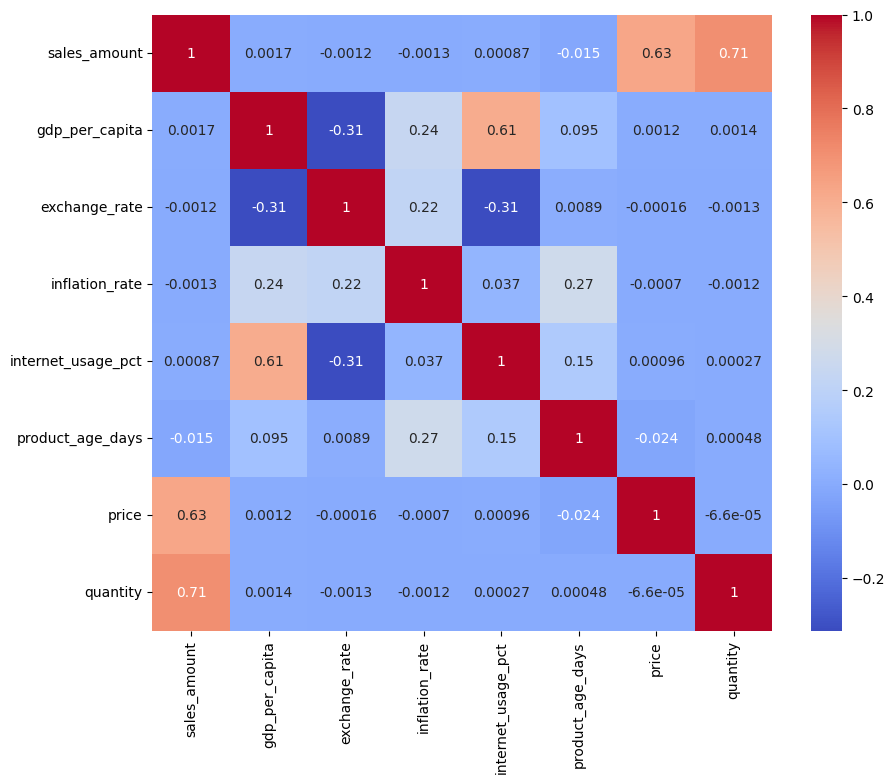

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    df[['sales_amount','gdp_per_capita','exchange_rate',
        'inflation_rate','internet_usage_pct',
        'product_age_days','price','quantity']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()


In [110]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 22 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   sale_id              1040200 non-null  object 
 1   sale_date            1040200 non-null  object 
 2   store_id             1040200 non-null  object 
 3   product_id           1040200 non-null  object 
 4   quantity             1040200 non-null  int64  
 5   product_name         1040200 non-null  object 
 6   launch_date          1040200 non-null  object 
 7   price                1040200 non-null  int64  
 8   store_name           1040200 non-null  object 
 9   city                 1040200 non-null  object 
 10  category_id          1040200 non-null  object 
 11  category_name        1040200 non-null  object 
 12  sales_amount         1040200 non-null  int64  
 13  invalid_launch_flag  1040200 non-null  bool   
 14  product_age_days     1040200 non-null  int64  
 15

,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita
count,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04
std,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04
min,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03
25%,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04
50%,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04
75%,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04
max,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04


In [111]:
df.sample(50)

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,sales_amount,invalid_launch_flag,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,country_norm_mapped,year,gdp_type,gdp_per_capita
274885,UB-0768,2021-04-14,ST-68,P-81,7,Apple Pencil (2nd Generation),2020-01-01,1506,Apple Champs-Elysees,Paris,...,10542,True,469,0.845494,1.642331,86.095500,france,2021,GDP_per_capita,43725.099950
404686,BV-3691,2021-11-23,ST-8,P-4,7,MacBook Pro 13-inch,2021-01-17,1351,Apple Pioneer Place,Portland,...,9457,False,310,1.000000,4.697859,91.268400,united states,2021,GDP_per_capita,71307.401730
714085,UA-769089,2023-05-05,ST-49,P-81,3,Apple Pencil (2nd Generation),2020-01-01,1506,Apple Yorkdale,Toronto,...,4518,True,1220,1.349909,3.879002,93.956400,canada,2023,GDP_per_capita,54220.328500
730372,PG-2439,2023-06-02,ST-40,P-75,7,HomePod mini,2020-01-02,266,Apple Causeway Bay,Hong Kong,...,1862,True,1247,7.083998,0.234837,90.600000,china,2023,GDP_per_capita,12951.178240
7771,CR-834856,2020-01-14,ST-48,P-74,8,HomePod,2020-01-01,1202,Apple Sainte-Catherine,Montreal,...,9616,True,13,1.341153,0.717000,92.300000,canada,2020,GDP_per_capita,43537.839300
380440,RS-83929,2021-10-12,ST-51,P-77,5,Magic Keyboard with Touch ID,2020-01-01,1162,Apple Sydney,Sydney,...,5810,True,650,1.331224,2.863910,96.972200,australia,2021,GDP_per_capita,60607.778860
1028245,SX-74632,2024-10-23,ST-32,P-8,6,MacBook Air (Retina),2020-01-16,1847,Apple Omotesando,Tokyo,...,11082,False,1742,151.366291,2.738537,86.270113,japan,2024,GDP_per_capita,32475.892500
853514,DE-88726,2023-12-30,ST-37,P-46,10,Apple Watch Ultra,2020-01-01,346,Apple Sanlitun,Beijing,...,3460,True,1459,7.083998,0.234837,90.600000,china,2023,GDP_per_capita,12951.178240
421829,BH-00067,2021-12-22,ST-27,P-52,2,Apple Watch Series 6,2020-01-01,462,Apple Rosenstrasse,Munich,...,924,True,721,0.845494,3.066667,91.430600,germany,2021,GDP_per_capita,52265.654160
166779,XM-71946,2020-10-11,ST-50,P-16,10,Beats Studio Buds,2020-01-01,762,Apple Metrotown,Burnaby,...,7620,True,284,1.341153,0.717000,92.300000,canada,2020,GDP_per_capita,43537.839300


In [112]:
import numpy as np
import pandas as pd

np.random.seed(42)

df = df.copy()
df['sale_date'] = pd.to_datetime(df['sale_date'])

# =====================================================
# 1️⃣ Seasonal Factor
# =====================================================

def seasonal_multiplier(month):
    if month == 11:
        return 1.3
    elif month == 12:
        return 1.5
    elif month == 1:
        return 0.8
    else:
        return 1.0

df['season_factor'] = df['sale_date'].dt.month.apply(seasonal_multiplier)

# =====================================================
# 2️⃣ Economic Factor
# =====================================================

df['economic_factor'] = (
    (df['gdp_per_capita'] / df['gdp_per_capita'].mean()) *
    (1 - df['inflation_rate'] / 100)
)

df['economic_factor'] = df['economic_factor'].clip(0.5, 1.5)

# =====================================================
# 3️⃣ Promotion
# =====================================================

df['promo_flag'] = np.random.choice([0,1], size=len(df), p=[0.9,0.1])
df['promo_factor'] = np.where(df['promo_flag']==1, 1.4, 1.0)

# =====================================================
# 4️⃣ Dynamic Pricing
# =====================================================

# base price inflation adjustment
df['price_realistic'] = (
    df['price'] *
    (1 + df['inflation_rate']/100)
)

# promotion discount
df.loc[df['promo_flag']==1, 'price_realistic'] *= 0.85

# small random volatility
df['price_realistic'] *= np.random.normal(1, 0.03, len(df))

# =====================================================
# 5️⃣ Product Trend (Lifecycle Simulation)
# =====================================================

df['days_from_start'] = (df['sale_date'] - df['sale_date'].min()).dt.days

product_trend_map = {
    pid: np.random.uniform(-0.0005, 0.0008)
    for pid in df['product_id'].unique()
}

df['product_trend'] = df['product_id'].map(product_trend_map)

df['trend_factor'] = 1 + df['product_trend'] * df['days_from_start']
df['trend_factor'] = df['trend_factor'].clip(0.5, 1.8)

# =====================================================
# 6️⃣ Store Heterogeneity
# =====================================================

store_effect_map = {
    sid: np.random.normal(1, 0.15)
    for sid in df['store_id'].unique()
}

df['store_factor'] = df['store_id'].map(store_effect_map)
df['store_factor'] = df['store_factor'].clip(0.6, 1.5)

# =====================================================
# 7️⃣ Base Mean Demand
# =====================================================

df['mu_demand'] = (
    df['quantity'] *
    df['season_factor'] *
    df['economic_factor'] *
    df['promo_factor'] *
    df['trend_factor'] *
    df['store_factor']
)

df['mu_demand'] = df['mu_demand'].clip(lower=0.1)

# =====================================================
# 8️⃣ Price Elasticity
# =====================================================

elasticity = -0.8

price_change_ratio = (
    (df['price_realistic'] - df['price']) / df['price']
)

df['mu_demand'] *= (1 + elasticity * price_change_ratio)
df['mu_demand'] = df['mu_demand'].clip(lower=0.1)

# =====================================================
# 9️⃣ Shock Event (مثلاً أزمة 2022)
# =====================================================

shock_mask = (
    (df['sale_date'] >= '2022-03-01') &
    (df['sale_date'] <= '2022-06-01')
)

df.loc[shock_mask, 'mu_demand'] *= 0.7

# =====================================================
# 🔟 Negative Binomial Demand Generation
# =====================================================

k = 1.8  # dispersion parameter

p = k / (k + df['mu_demand'])
r = k

df['quantity_realistic'] = np.random.negative_binomial(r, p)

# =====================================================
# 1️⃣1️⃣ Zero Inflation
# =====================================================

zero_mask = np.random.choice([0,1], size=len(df), p=[0.97,0.03])
df.loc[zero_mask==1, 'quantity_realistic'] = 0

# =====================================================
# 1️⃣2️⃣ Final Sales
# =====================================================

df['sales_amount_realistic'] = (
    df['quantity_realistic'] *
    df['price_realistic']
)


In [113]:
df.head()

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_flag,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,0,1.0,471.375260,0,0.000783,1.0,1.219421,1.002124,0,0.000000
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1,1.4,754.811217,0,0.000154,1.0,1.172288,9.008169,2,1509.622434
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,0,1.0,520.297395,0,0.000783,1.0,0.958735,6.909914,11,5723.271345
3,ZI-218670,2020-01-01,ST-20,P-70,1,Apple Fitness+,2020-01-01,923,Apple Kaerntner Strasse,Vienna,...,0,1.0,986.821602,0,0.000692,1.0,1.109330,0.860548,0,0.000000
4,VB-48589,2020-01-01,ST-60,P-18,9,Beats Solo Pro,2020-01-01,1773,Apple Antara,Mexico City,...,0,1.0,1754.958804,0,0.000495,1.0,1.203289,4.367104,4,7019.835216


In [114]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 34 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   sale_id                 1040200 non-null  object        
 1   sale_date               1040200 non-null  datetime64[ns]
 2   store_id                1040200 non-null  object        
 3   product_id              1040200 non-null  object        
 4   quantity                1040200 non-null  int64         
 5   product_name            1040200 non-null  object        
 6   launch_date             1040200 non-null  object        
 7   price                   1040200 non-null  int64         
 8   store_name              1040200 non-null  object        
 9   city                    1040200 non-null  object        
 10  category_id             1040200 non-null  object        
 11  category_name           1040200 non-null  object        
 12  sales_amount  

In [115]:
df.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_flag,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.000038e-01,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.515001e+00,6.317707e+00,6.770804e+03
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,0.000000e+00,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.233625e-01,0.000000e+00,0.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,0.000000e+00,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.549959e+00,1.000000e+00,9.643129e+02
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,0.000000e+00,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,5.007457e+00,3.000000e+00,3.205011e+03
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,0.000000e+00,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.831834e+00,8.000000e+00,8.254546e+03
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.000000e+00,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,8.070694e+01,2.600000e+02,3.662595e+05
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,3.000053e-01,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.513714e+00,8.710648e+00,1.057133e+04


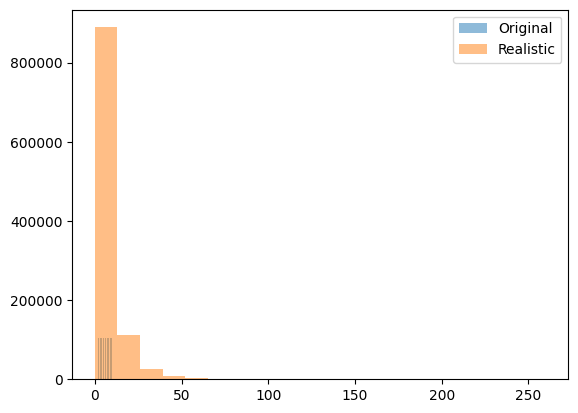

In [116]:
import matplotlib.pyplot as plt

plt.hist(df['quantity'], bins=20, alpha=0.5, label='Original')
plt.hist(df['quantity_realistic'], bins=20, alpha=0.5, label='Realistic')
plt.legend()
plt.show()


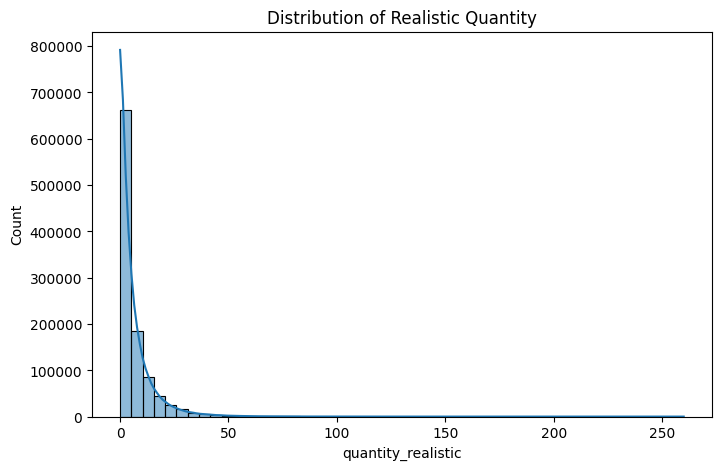

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['quantity_realistic'], bins=50, kde=True)
plt.title("Distribution of Realistic Quantity")
plt.show()


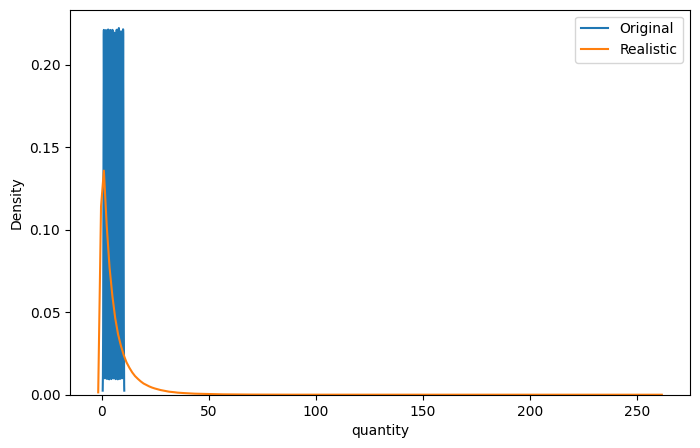

In [118]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['quantity'], label="Original")
sns.kdeplot(df['quantity_realistic'], label="Realistic")
plt.legend()
plt.show()


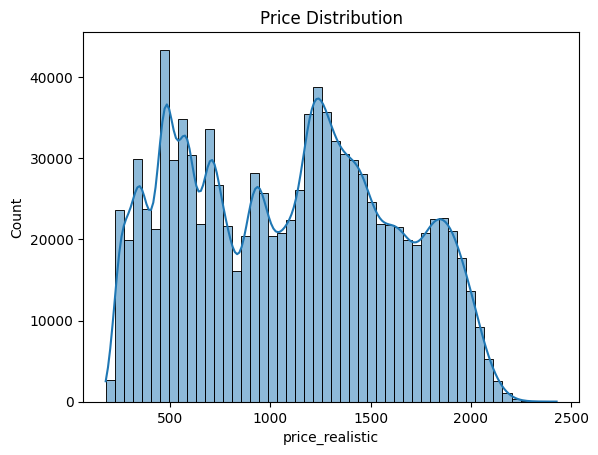

In [119]:
sns.histplot(df['price_realistic'], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()


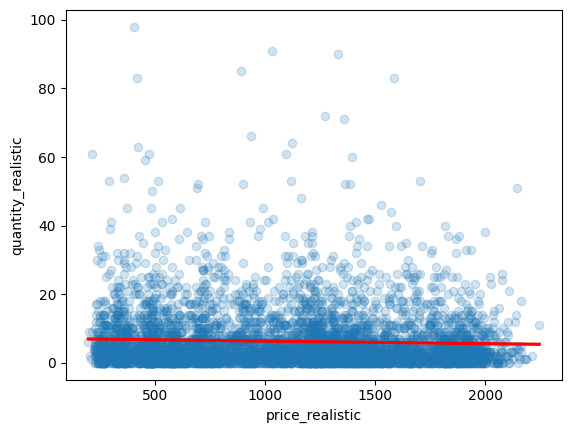

In [120]:
sns.regplot(x='price_realistic',
            y='quantity_realistic',
            data=df.sample(5000),
            scatter_kws={'alpha':0.2},
            line_kws={'color':'red'})
plt.show()


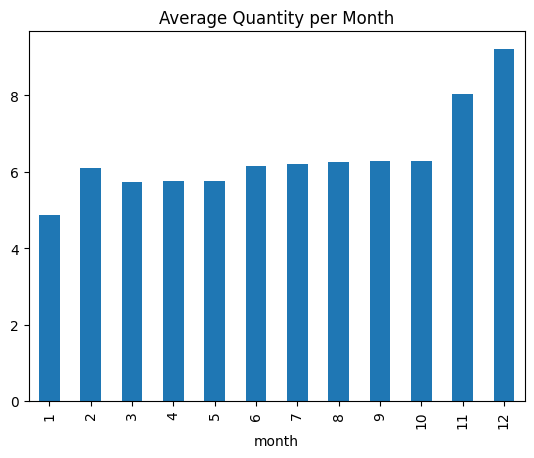

In [121]:
df['month'] = df['sale_date'].dt.month

monthly = df.groupby('month')['quantity_realistic'].mean()

monthly.plot(kind='bar')
plt.title("Average Quantity per Month")
plt.show()


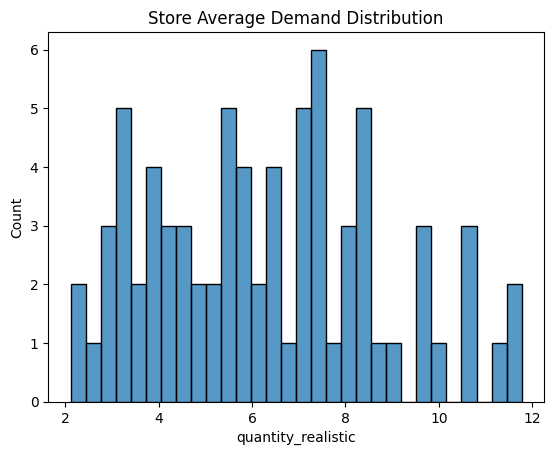

In [122]:
store_avg = df.groupby('store_id')['quantity_realistic'].mean()

sns.histplot(store_avg, bins=30)
plt.title("Store Average Demand Distribution")
plt.show()


<Axes: xlabel='sale_date'>

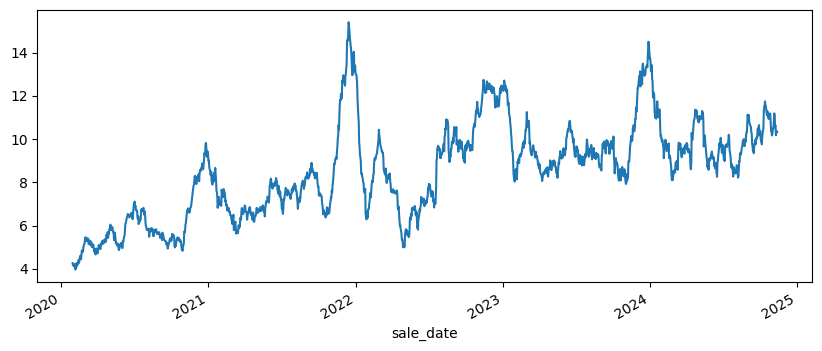

In [123]:
sample_product = df['product_id'].iloc[0]

df[df['product_id']==sample_product] \
    .groupby('sale_date')['quantity_realistic'] \
    .mean() \
    .rolling(30).mean() \
    .plot(figsize=(10,4))


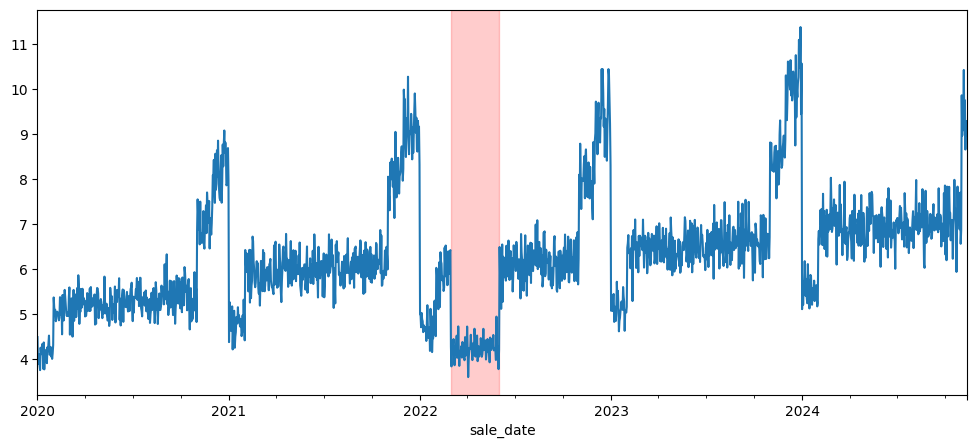

In [124]:
df.groupby('sale_date')['quantity_realistic'].mean().plot(figsize=(12,5))
plt.axvspan(pd.to_datetime('2022-03-01'),
            pd.to_datetime('2022-06-01'),
            color='red',
            alpha=0.2)
plt.show()


In [125]:
print("Mean:", df['quantity_realistic'].mean())
print("Variance:", df['quantity_realistic'].var())


Mean: 6.317707171697751
Variance: 75.87538677849575


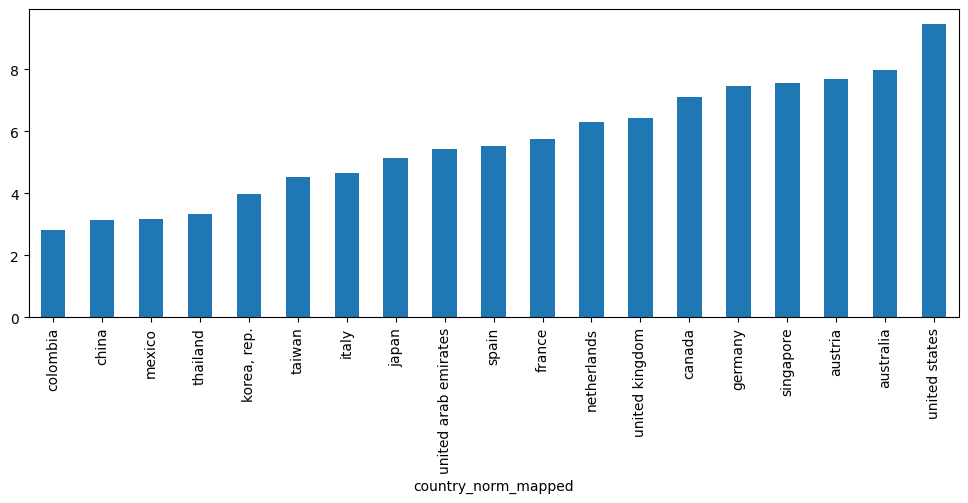

In [126]:
country_avg = df.groupby('country_norm_mapped')['quantity_realistic'].mean()

country_avg.sort_values().plot(kind='bar', figsize=(12,4))
plt.show()


In [127]:
# نزود قوة العلاقة العكسية
elasticity = -1.1  # بدل -0.8

price_change_ratio = (
    (df['price_realistic'] - df['price']) / df['price']
)

df['mu_demand'] *= (1 + elasticity * price_change_ratio)

df['mu_demand'] = df['mu_demand'].clip(lower=0.1)


In [128]:
# بدل 1.8
k = 2.8

p = k / (k + df['mu_demand'])
r = k

df['quantity_realistic'] = np.random.negative_binomial(r, p)


In [129]:
zero_mask = np.random.choice([0,1], size=len(df), p=[0.98,0.02])
df.loc[zero_mask==1, 'quantity_realistic'] = 0


In [130]:
upper_cap = df['quantity_realistic'].quantile(0.995)
df['quantity_realistic'] = df['quantity_realistic'].clip(upper=upper_cap)


In [131]:
df['sales_amount_realistic'] = (
    df['quantity_realistic'] *
    df['price_realistic']
)


In [132]:
print("Mean:", df['quantity_realistic'].mean())
print("Variance:", df['quantity_realistic'].var())
print("Max:", df['quantity_realistic'].max())


Mean: 6.245522976350702
Variance: 55.80067674598886
Max: 46


In [133]:
df_realistic = df.copy()
df_realistic.to_csv(PROC / "cleaned_apple_sales_enriched_realistic.csv", index=False)

In [134]:
df_realistic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   sale_id                 1040200 non-null  object        
 1   sale_date               1040200 non-null  datetime64[ns]
 2   store_id                1040200 non-null  object        
 3   product_id              1040200 non-null  object        
 4   quantity                1040200 non-null  int64         
 5   product_name            1040200 non-null  object        
 6   launch_date             1040200 non-null  object        
 7   price                   1040200 non-null  int64         
 8   store_name              1040200 non-null  object        
 9   city                    1040200 non-null  object        
 10  category_id             1040200 non-null  object        
 11  category_name           1040200 non-null  object        
 12  sales_amount  

In [135]:
df['sale_date'].min()

Timestamp('2020-01-01 00:00:00')

In [136]:
df['sale_date'].max()

Timestamp('2024-11-12 00:00:00')

In [137]:
df['sale_date'].dt.to_period('M').nunique()

59

In [138]:
df.groupby(['country_norm_mapped','store_id'])['sale_date'].min()

country_norm_mapped  store_id
australia            ST-51      2020-01-01
                     ST-52      2020-01-01
                     ST-53      2020-01-01
                     ST-54      2020-01-01
                     ST-55      2020-01-01
                                   ...    
united states        ST-5       2020-01-01
                     ST-6       2020-01-01
                     ST-7       2020-01-01
                     ST-8       2020-01-01
                     ST-9       2020-01-01
Name: sale_date, Length: 75, dtype: datetime64[ns]

In [139]:
monthly = df.groupby(['year','month'])['sales_amount_realistic'].sum().reset_index()
monthly.head()

,year,month,sales_amount_realistic
0,2020,1,8.071406e+07
1,2020,2,9.375707e+07
2,2020,3,1.039779e+08
3,2020,4,9.861240e+07
4,2020,5,1.023245e+08


C:\Users\Ali Sherif\AppData\Local\Temp\ipykernel_10736\1182431257.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = store_df.groupby(pd.Grouper(key='sale_date', freq='M'))['sales_amount_realistic'].sum()


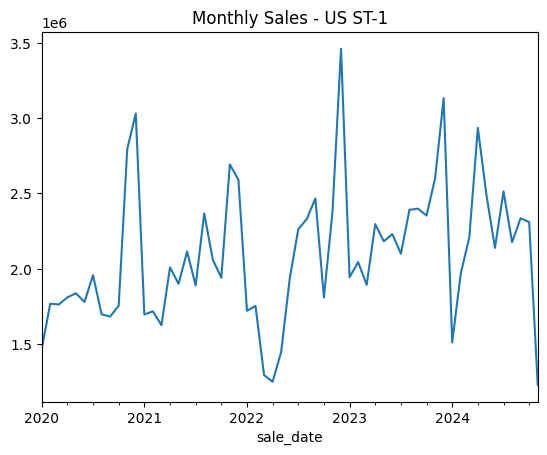

In [140]:
import matplotlib.pyplot as plt

store_df = df[(df['country_norm_mapped']=='united states') & 
              (df['store_id']=='ST-1')]

monthly = store_df.groupby(pd.Grouper(key='sale_date', freq='M'))['sales_amount_realistic'].sum()

plt.figure()
monthly.plot()
plt.title("Monthly Sales - US ST-1")
plt.show()

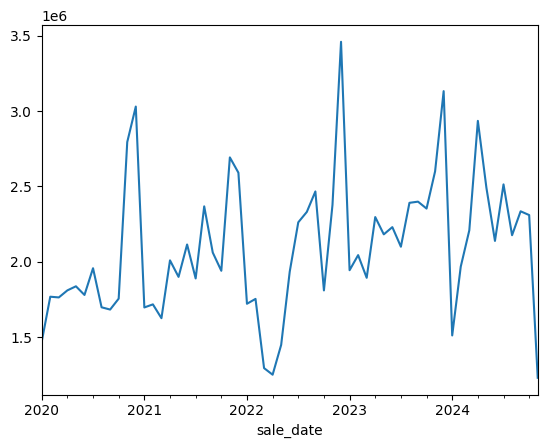

In [141]:
import matplotlib.pyplot as plt

plt.figure()
monthly.plot()
plt.show()

In [157]:
df_realistic.sample(10)

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month,revenue_temp
274885,UB-0768,2021-04-14,ST-68,P-81,7,Apple Pencil (2nd Generation),2020-01-01,1506,Apple Champs-Elysees,Paris,...,1437.711991,469,0.000208,1.097723,1.163143,8.934768,13,18690.255884,4,18690.255884
404686,BV-3691,2021-11-23,ST-8,P-4,7,MacBook Pro 13-inch,2021-01-17,1351,Apple Pioneer Place,Portland,...,1378.384632,692,-0.000143,0.901079,0.809810,9.273382,6,8270.307789,11,8270.307789
714085,UA-769089,2023-05-05,ST-49,P-81,3,Apple Pencil (2nd Generation),2020-01-01,1506,Apple Yorkdale,Toronto,...,1493.397383,1220,0.000208,1.254205,0.796929,3.392136,5,7466.986914,5,7466.986914
730372,PG-2439,2023-06-02,ST-40,P-75,7,HomePod mini,2020-01-02,266,Apple Causeway Bay,Hong Kong,...,275.414973,1248,0.000591,1.737677,0.860337,4.886345,6,1652.489837,6,1652.489837
7771,CR-834856,2020-01-14,ST-48,P-74,8,HomePod,2020-01-01,1202,Apple Sainte-Catherine,Montreal,...,1209.603210,13,-0.000363,0.995277,1.087753,6.322181,9,10886.428886,1,10886.428886
380440,RS-83929,2021-10-12,ST-51,P-77,5,Magic Keyboard with Touch ID,2020-01-01,1162,Apple Sydney,Sydney,...,1166.529123,650,-0.000036,0.976631,1.203033,7.334510,6,6999.174739,10,6999.174739
1028245,SX-74632,2024-10-23,ST-32,P-8,6,MacBook Air (Retina),2020-01-16,1847,Apple Omotesando,Tokyo,...,1578.369838,1757,-0.000203,0.643756,1.250931,5.911481,16,25253.917401,10,25253.917401
853514,DE-88726,2023-12-30,ST-37,P-46,10,Apple Watch Ultra,2020-01-01,346,Apple Sanlitun,Beijing,...,370.696628,1459,0.000195,1.284707,0.935741,7.833823,4,1482.786510,12,1482.786510
421829,BH-00067,2021-12-22,ST-27,P-52,2,Apple Watch Series 6,2020-01-01,462,Apple Rosenstrasse,Munich,...,492.421458,721,0.000509,1.367110,1.120681,4.371655,5,2462.107288,12,2462.107288
166779,XM-71946,2020-10-11,ST-50,P-16,10,Beats Studio Buds,2020-01-01,762,Apple Metrotown,Burnaby,...,762.383387,284,0.000208,1.059104,1.026704,10.032670,6,4574.300322,10,4574.300322


In [142]:
df_realistic.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.437436e+00,6.245523e+00,6.669167e+03,6.375341e+00
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.124592e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.482844e+00,1.000000e+00,1.221419e+03,3.000000e+00
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,4.896092e+00,4.000000e+00,3.556643e+03,6.000000e+00
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.671425e+00,8.000000e+00,8.465278e+03,9.000000e+00
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,9.504407e+01,4.600000e+01,1.025249e+05,1.200000e+01
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.614559e+00,7.469985e+00,9.152623e+03,3.387588e+00


In [143]:
df_realistic.isnull().sum()

sale_id                   0
sale_date                 0
store_id                  0
product_id                0
quantity                  0
product_name              0
launch_date               0
price                     0
store_name                0
city                      0
category_id               0
category_name             0
sales_amount              0
invalid_launch_flag       0
product_age_days          0
exchange_rate             0
inflation_rate            0
internet_usage_pct        0
country_norm_mapped       0
year                      0
gdp_type                  0
gdp_per_capita            0
season_factor             0
economic_factor           0
promo_flag                0
promo_factor              0
price_realistic           0
days_from_start           0
product_trend             0
trend_factor              0
store_factor              0
mu_demand                 0
quantity_realistic        0
sales_amount_realistic    0
month                     0
dtype: int64

In [144]:
df_realistic.sample(50)

,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
322319,GI-0158,2021-07-04,ST-29,P-43,5,iPhone 12 Pro,2020-01-01,1342,Apple Galeries Lafayette,Paris,...,1.0,1385.853313,550,0.000799,1.439639,0.858658,5.331954,6,8315.119881,7
496996,HP-2303,2022-04-29,ST-57,P-66,1,Mac Mini (M2),2021-10-30,874,Apple Yas Mall,Abu Dhabi,...,1.0,943.248442,849,-0.000399,0.661306,0.853664,0.341141,1,943.248442,4
724050,RM-30845,2023-05-23,ST-59,P-87,7,MagSafe Charger,2020-01-01,1744,Apple Mall of the Emirates,Dubai,...,1.0,1792.594469,1238,0.000579,1.716966,0.983243,11.543857,0,0.000000,5
201995,XT-94452,2020-12-11,ST-16,P-78,5,Magic Mouse,2020-01-01,313,Apple Regent Street,London,...,1.0,333.175953,345,0.000615,1.212044,1.166537,7.986650,8,2665.407621,12
821361,DN-53272,2023-11-05,ST-42,P-6,1,MacBook Pro 16-inch,2021-12-28,1179,Apple Orchard Road,Singapore,...,1.0,1209.337496,1404,0.000304,1.426945,0.672284,1.780292,7,8465.362470,11
561615,RZ-269448,2022-08-17,ST-9,P-77,3,Magic Keyboard with Touch ID,2020-01-01,1162,Apple Park Visitor Center,Cupertino,...,1.0,1182.665903,959,-0.000036,0.965522,0.958735,4.025959,9,10643.993129,8
4113,MV-66640,2020-01-08,ST-14,P-71,8,Apple Arcade,2020-01-01,549,Apple The Americana at Brand,Glendale,...,1.0,581.756227,7,-0.000364,0.997449,0.866628,6.689477,9,5235.806046,1
744636,UX-289497,2023-06-27,ST-52,P-1,9,MacBook,2020-01-01,1149,Apple Chadstone,Melbourne,...,1.0,1227.592545,1273,0.000328,1.417362,0.644214,9.393991,12,14731.110542,6
196821,DB-849283,2020-12-02,ST-61,P-24,3,iPad mini (6th Generation),2020-01-01,573,Apple Santa Fe,Mexico City,...,1.0,582.302621,336,0.000466,1.156715,1.086308,2.740680,2,1164.605241,12
522113,AB-601712,2022-06-10,ST-4,P-58,9,iMac 27-inch,2022-05-17,1918,Apple The Grove,Los Angeles,...,1.0,2014.171378,891,-0.000322,0.713433,1.133018,9.897014,3,6042.514133,6


In [145]:
df_realistic['quantity_realistic'].value_counts()

quantity_realistic
0     147202
1     134388
2     116529
3      97571
4      81351
5      67203
6      56017
7      46914
8      39661
9      33128
10     28351
11     24121
12     20724
13     17752
14     15242
15     13284
16     11555
17     10088
18      8785
19      7491
20      6647
21      5861
46      5363
22      5298
23      4634
24      4029
25      3524
26      3113
27      2872
28      2540
29      2375
30      1964
31      1736
32      1662
33      1492
34      1317
35      1252
36      1077
37       970
38       885
39       767
40       722
41       672
42       627
43       541
44       466
45       437
Name: count, dtype: int64

In [146]:
df_realistic.describe()

,sale_date,quantity,price,sales_amount,product_age_days,exchange_rate,inflation_rate,internet_usage_pct,year,gdp_per_capita,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
count,1040200,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,...,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06,1.040200e+06
mean,2022-06-07 16:51:18.598730752,5.500235e+00,1.077787e+03,5.927988e+03,6.119623e+02,1.542778e+02,3.247802e+00,8.999657e+01,2.021946e+03,4.680516e+04,...,1.040002e+00,1.096057e+03,8.887023e+02,1.674567e-04,1.138149e+00,9.951873e-01,6.437436e+00,6.245523e+00,6.669167e+03,6.375341e+00
min,2020-01-01 00:00:00,1.000000e+00,2.310000e+02,2.310000e+02,0.000000e+00,7.270649e-01,-2.079403e+00,6.979530e+01,2.020000e+03,5.339687e+03,...,1.000000e+00,1.788246e+02,0.000000e+00,-4.962412e-04,5.000000e-01,6.442142e-01,1.124592e-01,0.000000e+00,0.000000e+00,1.000000e+00
25%,2021-03-20 00:00:00,3.000000e+00,6.230000e+02,2.362000e+03,2.420000e+02,1.000000e+00,1.233584e+00,8.698150e+01,2.021000e+03,3.350901e+04,...,1.000000e+00,6.294309e+02,4.440000e+02,-1.429487e-04,9.299385e-01,8.603374e-01,2.482844e+00,1.000000e+00,1.221419e+03,3.000000e+00
50%,2022-06-07 00:00:00,5.000000e+00,1.149000e+03,4.770000e+03,5.380000e+02,1.349909e+00,2.863910e+00,9.200000e+01,2.022000e+03,4.904069e+04,...,1.000000e+00,1.128185e+03,8.880000e+02,1.951382e-04,1.074579e+00,9.869100e-01,4.896092e+00,4.000000e+00,3.556643e+03,6.000000e+00
75%,2023-08-27 00:00:00,8.000000e+00,1.436000e+03,8.694000e+03,9.270000e+02,7.083998e+00,4.878357e+00,9.481820e+01,2.023000e+03,6.440748e+04,...,1.000000e+00,1.492781e+03,1.334000e+03,4.945074e-04,1.372622e+00,1.133018e+00,8.671425e+00,8.000000e+00,8.465278e+03,9.000000e+00
max,2024-11-12 00:00:00,1.000000e+01,1.965000e+03,1.965000e+04,1.777000e+03,4.325955e+03,1.173590e+01,1.000000e+02,2.024000e+03,9.067407e+04,...,1.400000e+00,2.427058e+03,1.777000e+03,7.993439e-04,1.800000e+00,1.469524e+00,9.504407e+01,4.600000e+01,1.025249e+05,1.200000e+01
std,NaN,2.874295e+00,4.986517e+02,4.376276e+03,4.323309e+02,6.699082e+02,2.625053e+00,7.550380e+00,1.393893e+00,2.361469e+04,...,1.200021e-01,5.123379e+02,5.132911e+02,3.862175e-04,3.569842e-01,1.715577e-01,5.614559e+00,7.469985e+00,9.152623e+03,3.387588e+00


In [147]:
zero_count = (df['quantity_realistic'] == 0).sum()
total = len(df)

print("Zero count:", zero_count)
print("Zero percentage:", zero_count / total * 100)


Zero count: 147202
Zero percentage: 14.151317054412612


In [148]:
df_daily = df.groupby(
    ['sale_date','store_id','product_id']
).agg({
    'quantity_realistic':'sum',
    'price_realistic':'mean'
}).reset_index()


In [149]:
df_daily.shape

(995690, 5)

In [150]:
df_realistic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1040200 entries, 0 to 1040199
Data columns (total 35 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   sale_id                 1040200 non-null  object        
 1   sale_date               1040200 non-null  datetime64[ns]
 2   store_id                1040200 non-null  object        
 3   product_id              1040200 non-null  object        
 4   quantity                1040200 non-null  int64         
 5   product_name            1040200 non-null  object        
 6   launch_date             1040200 non-null  object        
 7   price                   1040200 non-null  int64         
 8   store_name              1040200 non-null  object        
 9   city                    1040200 non-null  object        
 10  category_id             1040200 non-null  object        
 11  category_name           1040200 non-null  object        
 12  sales_amount  

In [151]:
# أولًا نحسب revenue لو مش موجود
df_realistic['revenue_temp'] = (
    df_realistic['price_realistic'] *
    df_realistic['quantity_realistic']
)

# نعمل aggregation vectorized
df_daily = (
    df_realistic
    .groupby(['sale_date', 'store_id', 'product_id'], as_index=False)
    .agg({
        'quantity_realistic': 'sum',
        'revenue_temp': 'sum',
        'product_name': 'first',
        'category_id': 'first',
        'category_name': 'first',
        'store_name': 'first',
        'city': 'first',
        'country_norm_mapped': 'first',
        'exchange_rate': 'mean',
        'inflation_rate': 'mean',
        'gdp_per_capita': 'mean',
        'internet_usage_pct': 'mean',
        'promo_flag': 'max',
        'year': 'first',
        'month': 'first'
    })
)

# نحسب weighted price بسرعة
df_daily['price_realistic'] = (
    df_daily['revenue_temp'] /
    df_daily['quantity_realistic']
)

# نشيل العمود المؤقت
df_daily.drop(columns=['revenue_temp'], inplace=True)
df_daily.shape
df_daily.info()
df_daily.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995690 entries, 0 to 995689
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sale_date            995690 non-null  datetime64[ns]
 1   store_id             995690 non-null  object        
 2   product_id           995690 non-null  object        
 3   quantity_realistic   995690 non-null  int32         
 4   product_name         995690 non-null  object        
 5   category_id          995690 non-null  object        
 6   category_name        995690 non-null  object        
 7   store_name           995690 non-null  object        
 8   city                 995690 non-null  object        
 9   country_norm_mapped  995690 non-null  object        
 10  exchange_rate        995690 non-null  float64       
 11  inflation_rate       995690 non-null  float64       
 12  gdp_per_capita       995690 non-null  float64       
 13  internet_usage

,sale_date,quantity_realistic,exchange_rate,inflation_rate,gdp_per_capita,internet_usage_pct,promo_flag,year,month,price_realistic
count,995690,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,859824.000000
mean,2022-06-07 17:28:07.370968320,6.524715,154.226893,3.248501,46809.095354,89.995375,0.104016,2021.945840,6.376155,1092.143399
min,2020-01-01 00:00:00,0.000000,0.727065,-2.079403,5339.687114,69.795300,0.000000,2020.000000,1.000000,178.824608
25%,2021-03-20 00:00:00,1.000000,1.000000,1.233584,33509.012800,86.981500,0.000000,2021.000000,3.000000,623.979499
50%,2022-06-07 00:00:00,4.000000,1.349909,2.863910,49040.694750,92.000000,0.000000,2022.000000,6.000000,1121.795136
75%,2023-08-26 00:00:00,9.000000,7.083998,4.878357,64407.484260,94.818200,0.000000,2023.000000,9.000000,1491.374597
max,2024-11-12 00:00:00,112.000000,4325.955000,11.735904,90674.066630,100.000000,1.000000,2024.000000,12.000000,2427.058417
std,NaN,7.811987,669.900097,2.625305,23617.950903,7.552562,0.305282,1.393707,3.387909,513.016319


In [152]:
df_daily.shape

(995690, 18)

In [153]:
df_daily.info()
df_daily.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995690 entries, 0 to 995689
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sale_date            995690 non-null  datetime64[ns]
 1   store_id             995690 non-null  object        
 2   product_id           995690 non-null  object        
 3   quantity_realistic   995690 non-null  int32         
 4   product_name         995690 non-null  object        
 5   category_id          995690 non-null  object        
 6   category_name        995690 non-null  object        
 7   store_name           995690 non-null  object        
 8   city                 995690 non-null  object        
 9   country_norm_mapped  995690 non-null  object        
 10  exchange_rate        995690 non-null  float64       
 11  inflation_rate       995690 non-null  float64       
 12  gdp_per_capita       995690 non-null  float64       
 13  internet_usage

,sale_date,quantity_realistic,exchange_rate,inflation_rate,gdp_per_capita,internet_usage_pct,promo_flag,year,month,price_realistic
count,995690,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,859824.000000
mean,2022-06-07 17:28:07.370968320,6.524715,154.226893,3.248501,46809.095354,89.995375,0.104016,2021.945840,6.376155,1092.143399
min,2020-01-01 00:00:00,0.000000,0.727065,-2.079403,5339.687114,69.795300,0.000000,2020.000000,1.000000,178.824608
25%,2021-03-20 00:00:00,1.000000,1.000000,1.233584,33509.012800,86.981500,0.000000,2021.000000,3.000000,623.979499
50%,2022-06-07 00:00:00,4.000000,1.349909,2.863910,49040.694750,92.000000,0.000000,2022.000000,6.000000,1121.795136
75%,2023-08-26 00:00:00,9.000000,7.083998,4.878357,64407.484260,94.818200,0.000000,2023.000000,9.000000,1491.374597
max,2024-11-12 00:00:00,112.000000,4325.955000,11.735904,90674.066630,100.000000,1.000000,2024.000000,12.000000,2427.058417
std,NaN,7.811987,669.900097,2.625305,23617.950903,7.552562,0.305282,1.393707,3.387909,513.016319


In [154]:
# رتب الداتا الأول
df_daily = df_daily.sort_values(
    ['store_id', 'product_id', 'sale_date']
)

# Fill forward لكل store × product
df_daily['price_realistic'] = (
    df_daily
    .groupby(['store_id', 'product_id'])['price_realistic']
    .ffill()
)

# لو أول يوم كان NaN (مفيش سعر قبله)
df_daily['price_realistic'] = (
    df_daily
    .groupby(['store_id', 'product_id'])['price_realistic']
    .bfill()
)


In [155]:
df_daily.info()
df_daily.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 995690 entries, 14991 to 995689
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   sale_date            995690 non-null  datetime64[ns]
 1   store_id             995690 non-null  object        
 2   product_id           995690 non-null  object        
 3   quantity_realistic   995690 non-null  int32         
 4   product_name         995690 non-null  object        
 5   category_id          995690 non-null  object        
 6   category_name        995690 non-null  object        
 7   store_name           995690 non-null  object        
 8   city                 995690 non-null  object        
 9   country_norm_mapped  995690 non-null  object        
 10  exchange_rate        995690 non-null  float64       
 11  inflation_rate       995690 non-null  float64       
 12  gdp_per_capita       995690 non-null  float64       
 13  internet_usage_

,sale_date,quantity_realistic,exchange_rate,inflation_rate,gdp_per_capita,internet_usage_pct,promo_flag,year,month,price_realistic
count,995690,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000,995690.000000
mean,2022-06-07 17:28:07.370968832,6.524715,154.226893,3.248501,46809.095354,89.995375,0.104016,2021.945840,6.376155,1094.492252
min,2020-01-01 00:00:00,0.000000,0.727065,-2.079403,5339.687114,69.795300,0.000000,2020.000000,1.000000,178.824608
25%,2021-03-20 00:00:00,1.000000,1.000000,1.233584,33509.012800,86.981500,0.000000,2021.000000,3.000000,628.379535
50%,2022-06-07 00:00:00,4.000000,1.349909,2.863910,49040.694750,92.000000,0.000000,2022.000000,6.000000,1126.062471
75%,2023-08-26 00:00:00,9.000000,7.083998,4.878357,64407.484260,94.818200,0.000000,2023.000000,9.000000,1490.538532
max,2024-11-12 00:00:00,112.000000,4325.955000,11.735904,90674.066630,100.000000,1.000000,2024.000000,12.000000,2427.058417
std,NaN,7.811987,669.900097,2.625305,23617.950903,7.552562,0.305282,1.393707,3.387909,511.618537


In [156]:
df_daily.to_csv(PROC / "cleaned_apple_sales_daily.csv", index=False)

In [158]:
import pandas as pd
import numpy as np

# تأكد إن التاريخ datetime
df['sale_date'] = pd.to_datetime(df['sale_date'])

# =========================
# 1️⃣ Monthly Aggregation
# =========================
monthly = (
    df
    .groupby([
        'country_norm_mapped',
        'store_id',
        pd.Grouper(key='sale_date', freq='ME')
    ])['sales_amount_realistic']
    .sum()
    .reset_index()
)

monthly = monthly.sort_values(['country_norm_mapped','store_id','sale_date'])

# =========================
# 2️⃣ Lag Features
# =========================
lags = [1,2,3,6,12]

for lag in lags:
    monthly[f'lag_{lag}'] = (
        monthly
        .groupby(['country_norm_mapped','store_id'])['sales_amount_realistic']
        .shift(lag)
    )

# =========================
# 3️⃣ Rolling Features
# =========================
monthly['rolling_mean_3'] = (
    monthly
    .groupby(['country_norm_mapped','store_id'])['sales_amount_realistic']
    .shift(1)
    .rolling(3)
    .mean()
)

monthly['rolling_std_6'] = (
    monthly
    .groupby(['country_norm_mapped','store_id'])['sales_amount_realistic']
    .shift(1)
    .rolling(6)
    .std()
)

# =========================
# 4️⃣ Time Features
# =========================
monthly['month'] = monthly['sale_date'].dt.month
monthly['year'] = monthly['sale_date'].dt.year
monthly['quarter'] = monthly['sale_date'].dt.quarter

monthly['month_sin'] = np.sin(2 * np.pi * monthly['month'] / 12)
monthly['month_cos'] = np.cos(2 * np.pi * monthly['month'] / 12)

# =========================
# 5️⃣ Log Transform (اختياري لكن مفضل)
# =========================
monthly['target_log'] = np.log1p(monthly['sales_amount_realistic'])

# =========================
# 6️⃣ Drop NaNs
# =========================
monthly = monthly.dropna().reset_index(drop=True)

monthly.head()

,country_norm_mapped,store_id,sale_date,sales_amount_realistic,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_std_6,month,year,quarter,month_sin,month_cos,target_log
0,australia,ST-51,2021-01-31,2.009279e+06,2.733613e+06,2.802823e+06,2.002390e+06,1.967326e+06,1.548129e+06,2.512942e+06,438315.846333,1,2021,1,0.500000,8.660254e-01,14.513287
1,australia,ST-51,2021-02-28,2.290813e+06,2.009279e+06,2.733613e+06,2.802823e+06,1.905526e+06,1.325129e+06,2.515238e+06,434025.238046,2,2021,1,0.866025,5.000000e-01,14.644418
2,australia,ST-51,2021-03-31,2.241242e+06,2.290813e+06,2.009279e+06,2.733613e+06,1.835399e+06,1.830223e+06,2.344568e+06,406754.669711,3,2021,1,1.000000,6.123234e-17,14.622541
3,australia,ST-51,2021-04-30,2.297937e+06,2.241242e+06,2.290813e+06,2.009279e+06,2.002390e+06,1.773240e+06,2.180445e+06,347676.891900,4,2021,2,0.866025,-5.000000e-01,14.647523
4,australia,ST-51,2021-05-31,2.581544e+06,2.297937e+06,2.241242e+06,2.290813e+06,2.802823e+06,1.820352e+06,2.276664e+06,307789.110411,5,2021,2,0.500000,-8.660254e-01,14.763899
